In [ ]:
from utils import *

# Strong = ['B97', 'U07']
# Weak = ['Z20', 'B34', 'R50', 'R05', 'R06', 'J12', 'J18', 'J20', 'J40', 'J21', 'J96', 'J22', 'J06', 'J98', 'J80', 'R43', 'R07', 'R68']
Strong = ['COVID-19']
Weak = ['Viral_infection', 'Contact_with_and_(suspected)_exposure_to_communicable_diseases', 'Adverse_drug_events_and_drug_allergies', 'Other_symptoms_of_respiratory_system', 
        'Respiratory_abnormalities', 'Pneumonia', 'Acute_bronchitis_and_bronchiolitis', 'Bronchitis', 'Respiratory_failure__insufficiency__arrest', 
        'Other_diseases_of_respiratory_system__not_elsewhere_classified', 'Acute_upper_respiratory_infections_of_multiple_or_unspecified_sites', 
        'Abnormal_movement', 'Throat_pain', 'Hypothermia_Chills']

# Flu1 = ['J09', 'J10', 'J11']
# Flu2 = ['J12', 'J13', 'J14', 'J15', 'J16', 'J17', 'J18']
# Flu3 = ['J00', 'J01', 'J02', 'J03', 'J04', 'J05', 'J06', 'J20', 'J21', 'J22', 'J40', 'R05', 'H66', 'R50', 'B97']
# Flu1 = ['Influenza']
# Flu2 = ['Pneumonia']
# Flu3 = ['Acute_upper_respiratory_infections_of_multiple_or_unspecified_sites', 'Acute_sinusitis', 'Acute_and_chronic_tonsillitis', 
#         'Acute_bronchitis_and_bronchiolitis', 'Other_diseases_of_respiratory_system__not_elsewhere_classified', 'Bronchitis', 
#         'Other_symptoms_of_respiratory_system', 'Otitis_media_and_Eustachian_tube_disorders', 'Adverse_drug_events_and_drug_allergies', 'Viral_infection']

warnings.filterwarnings("ignore")
lag_set = np.array([14, 7, 0])
group_size = len(lag_set)
report_freq_days = 1
lag_set = (lag_set / report_freq_days).astype(int)
state_list = state_abbr

train_period = 210
validation_period = 140
intercept_length = validation_period
test_period = 350
step_size = 70

dataset_list = ['JHUcase', 'JHUdeath', 'HHShospitalized']
# dataset_list = ['HHSflu']
method_list = ['Strong', 'Weak']

dataset = 'HHShospitalized'
target_data = pd.read_csv('../data/' + dataset + '.txt', index_col = 0)
target_data = target_data.loc[:, state_list].astype(float)
if report_freq_days == 1:
    target_data = target_data.apply(moving_average_smoother).iloc[6:]
target_dates = target_data.index
state_data_dict = {}
for state in state_list:
    if report_freq_days == 1:
        state_data = pd.read_csv(f'../data/{state}phecodes.csv', index_col = 0, header = 0).astype(float).apply(moving_average_smoother).iloc[6:]
    elif report_freq_days == 7:
        state_data = pd.read_csv(f'../data/{state}phecodes.csv', index_col = 0, header = 0).astype(float).rolling(window=7, min_periods=1).sum().iloc[6:]
    state_data_dict[state] = state_data[state_data.index.isin(target_dates)]
all_codes = state_data_dict[state_list[0]].columns.to_numpy()

train_start_date_list = []
validation_start_date_list = []
test_start_date_list = []
# train_start_date = date_after(max(min(target_data.index), min(state_data_dict[state].index)), max(lag_set) * report_freq_days)
train_start_date = 20210201
validation_start_date = date_after(train_start_date, train_period)
test_start_date = date_after(validation_start_date, validation_period)
while test_start_date < 20220901:
# while test_start_date < 20230401:
    train_start_date_list.append(train_start_date)
    validation_start_date_list.append(validation_start_date)
    test_start_date_list.append(test_start_date)
    train_start_date = date_after(train_start_date, step_size)
    validation_start_date = date_after(train_start_date, train_period)
    test_start_date = date_after(validation_start_date, validation_period)

data_handler = HealthDataHandler(state_list, lag_set, report_freq_days, target_data, state_data_dict)
    
DiagnosisCodeSet = Strong + Weak
active_g_indices = np.where(np.isin(all_codes, DiagnosisCodeSet))[0]
active_v_indices = extend_indices(active_g_indices, group_size)
y_dict = {}
pred_dict = {}
pred_agg_dict = {}
date_plot_list = []
for state in state_list:
    y_dict[state] = []
    pred_dict[state] = []
    pred_agg_dict[state] = []

selection = False
# for d_idx in range(len(train_start_date_list)):
d_idx = 0
data_handler.get_X_y(start_date = train_start_date_list[d_idx], end_date = validation_start_date_list[d_idx], codes = all_codes)
data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = validation_period)
print(train_start_date_list[d_idx], '-', test_start_date_list[d_idx])

# data_handler.run_all_single(intercept_length, method, alpha = 0.2, states_prev_g = states_prev_g, maxsteps = 4, states_prev_W = states_prev_W, tau = 0.5, M = 10, M_max = 30, fdr = 0.1)
data_handler.recovered_coef = {}
data_handler.recovered_intercept = {}
for state in state_list:
    grouped_X = data_handler.grouped_X[state]
    y = data_handler.y[state]
    X_active = grouped_X[:, active_v_indices]
    extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
    beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
    recovered_coef = np.zeros(grouped_X.shape[1])
    recovered_coef[active_v_indices] = beta[1:]
    recovered_intercept = recover_intercept(grouped_X, y, recovered_coef, intercept_length)
    data_handler.recovered_coef[state] = recovered_coef
    data_handler.recovered_intercept[state] = recovered_intercept

data_handler.run_all_agg(intercept_length, state_method = 'marginal_diff', auxiliary_state_list = None, nStates = 5, total_step = 10, selection = selection)

data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = test_period)
date_plot_list.append([datetime.strptime(str(d), '%Y%m%d') for d in data_handler.test_dates])
for state in state_list:
    y_dict[state].append(data_handler.y_test[state])
    pred_dict[state].append(np.dot(data_handler.grouped_X_test[state], data_handler.recovered_coef[state]) + data_handler.recovered_intercept[state])
    pred_agg_dict[state].append(np.dot(data_handler.grouped_X_test[state], data_handler.recovered_coef_agg[state]) + data_handler.recovered_intercept_agg[state])

for state in ['PA', 'NY', 'NJ', 'MA', 'OH', 'VA', 'MD', 'CT', 'RI']:
    plt.figure(figsize=(10, 6))
    plt.plot(date_plot_list[d_idx], y_dict[state][d_idx], c = 'k', lw = 2)
    plt.plot(date_plot_list[d_idx], pred_dict[state][d_idx], alpha = 0.8, c = 'r', lw = 1, label = 'single model')
    plt.plot(date_plot_list[d_idx], pred_agg_dict[state][d_idx], alpha = 0.8, c = 'g', lw = 1, label = 'aggregated model')
    plt.legend()
    plt.title(state)
    plt.xticks(rotation = 30)
    


In [7]:
from utils import *

warnings.filterwarnings("ignore")
lag_set = np.array([14, 7, 0])
group_size = len(lag_set)
report_freq_days = 1
lag_set = (lag_set / report_freq_days).astype(int)
state_list = state_abbr

train_period = 210
validation_period = 140
intercept_length = validation_period
test_period = 350
step_size = 70

dataset_list = ['JHUcase', 'JHUdeath', 'HHShospitalized']
# dataset_list = ['HHSflu']
method_list = ['Strong', 'Weak']

target_data = pd.read_csv('/Users/ruiqil/Documents/PheOpt/all_states/HHShospitalized.csv', index_col = 0)
target_data = target_data.loc[:, state_list].astype(float)
if report_freq_days == 1:
    target_data = target_data.apply(moving_average_smoother).iloc[6:]
target_dates = target_data.index

train_start_date_list = []
validation_start_date_list = []
test_start_date_list = []
# train_start_date = date_after(max(min(target_data.index), min(state_data_dict[state].index)), max(lag_set) * report_freq_days)
train_start_date = 20210201
validation_start_date = date_after(train_start_date, train_period)
test_start_date = date_after(validation_start_date, validation_period)
while test_start_date < 20220901:
# while test_start_date < 20230401:
    train_start_date_list.append(train_start_date)
    validation_start_date_list.append(validation_start_date)
    test_start_date_list.append(test_start_date)
    train_start_date = date_after(train_start_date, step_size)
    validation_start_date = date_after(train_start_date, train_period)
    test_start_date = date_after(validation_start_date, validation_period)
d_idx = 0
start_test = validation_start_date_list[d_idx]
period_length = test_period
end_test = date_after(start_test, period_length)
target_data = target_data.loc[start_test:end_test - report_freq_days, :]
test_dates = target_data.index.to_numpy()

In [9]:
correlation_matrix = target_data.corr()

In [11]:
correlation_matrix['MA']

AL    0.499329
AK    0.018909
AZ    0.695794
AR    0.611490
CA    0.769849
CO    0.589195
CT    0.984460
DE    0.937086
DC    0.935977
FL    0.501608
GA    0.555522
HI    0.453216
ID    0.200349
IL    0.942740
IN    0.728342
IA    0.705339
KS    0.788322
KY    0.542886
LA    0.592953
ME    0.821641
MD    0.951655
MA    1.000000
MI    0.740937
MN    0.677163
MS    0.590533
MO    0.838544
MT    0.124662
NE    0.677183
NV    0.750497
NH    0.754167
NJ    0.967485
NM    0.621146
NY    0.984883
NC    0.656234
OH    0.776363
OK    0.644601
OR    0.370656
PA    0.872293
RI    0.966345
SC    0.507738
SD    0.655470
TN    0.493805
TX    0.521115
UT    0.542856
VT    0.804291
VA    0.836032
WA    0.636468
WV    0.483783
WI    0.797305
WY    0.086311
PR    0.710790
Name: MA, dtype: float64

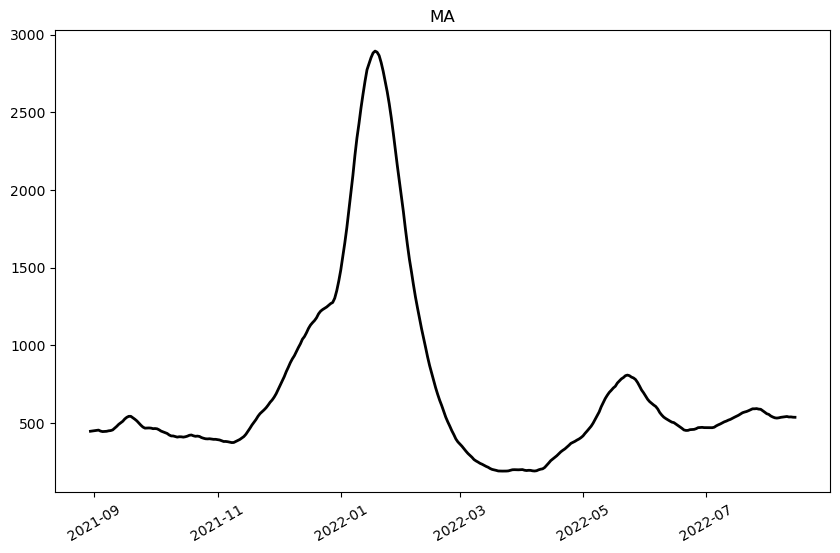

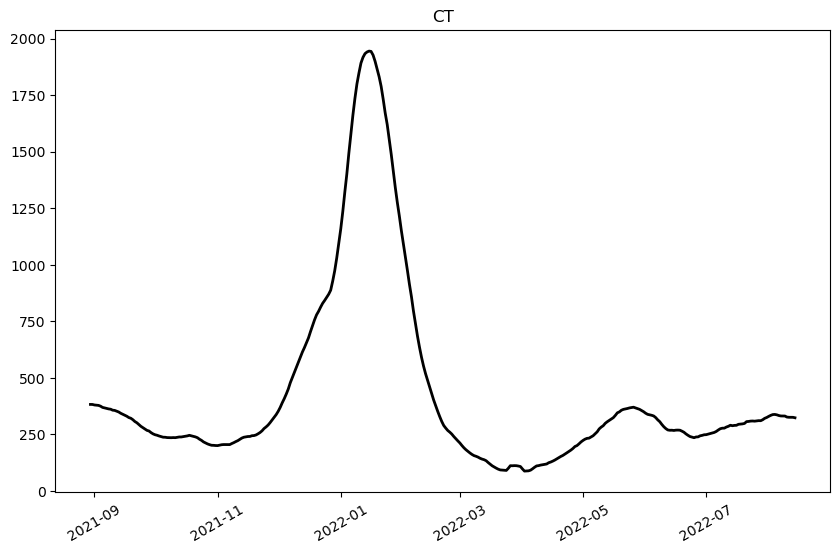

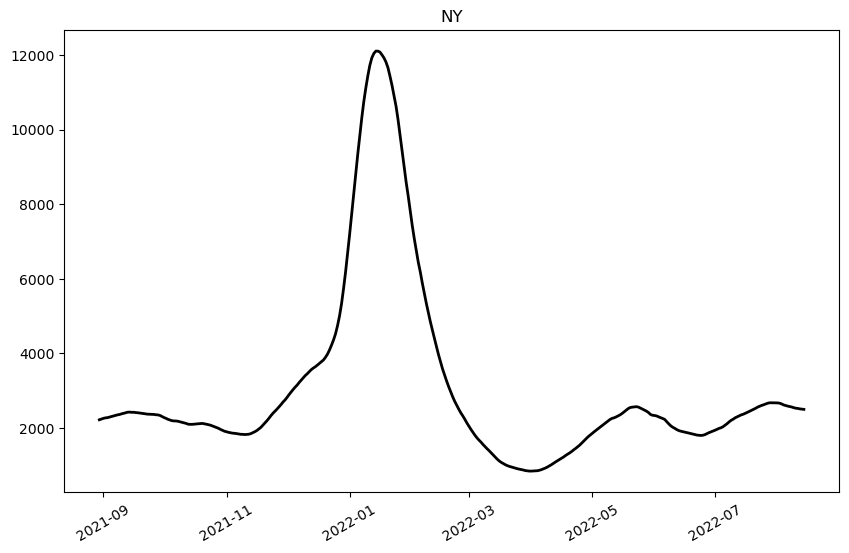

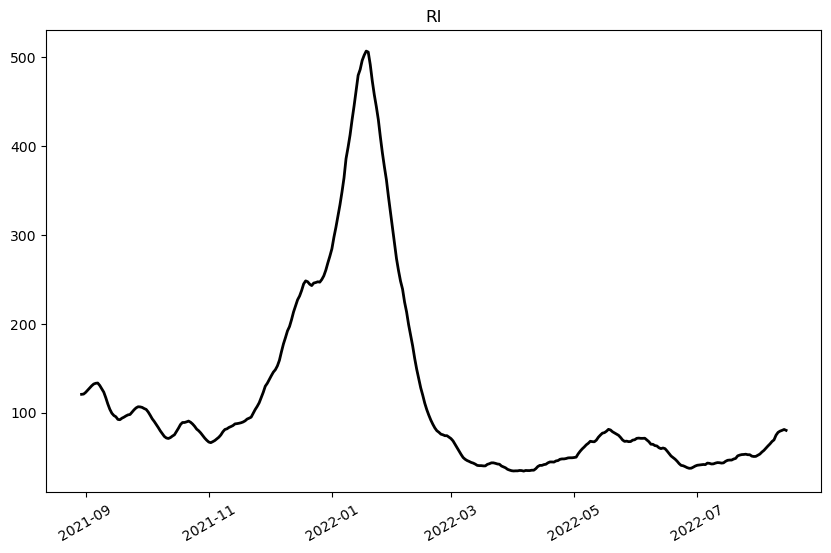

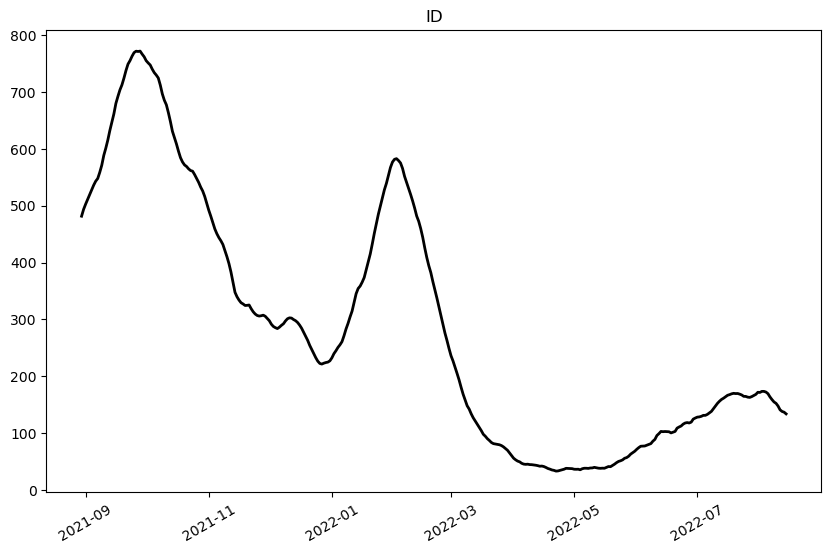

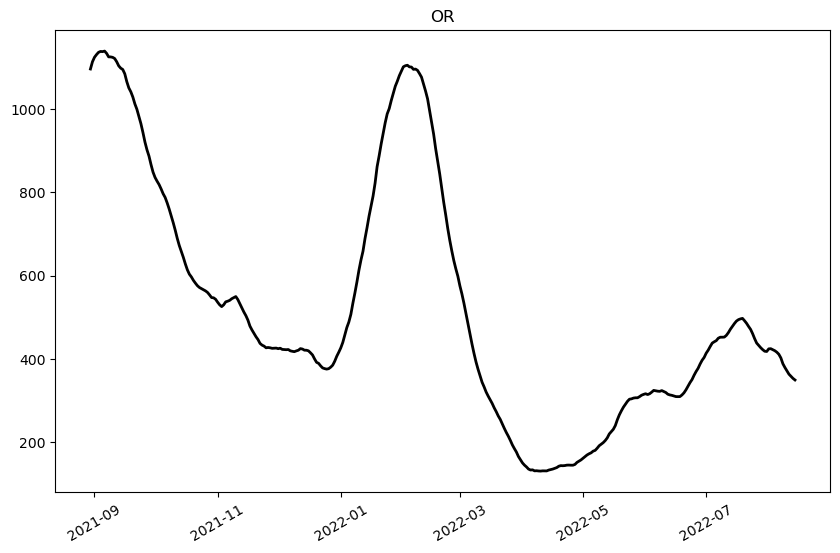

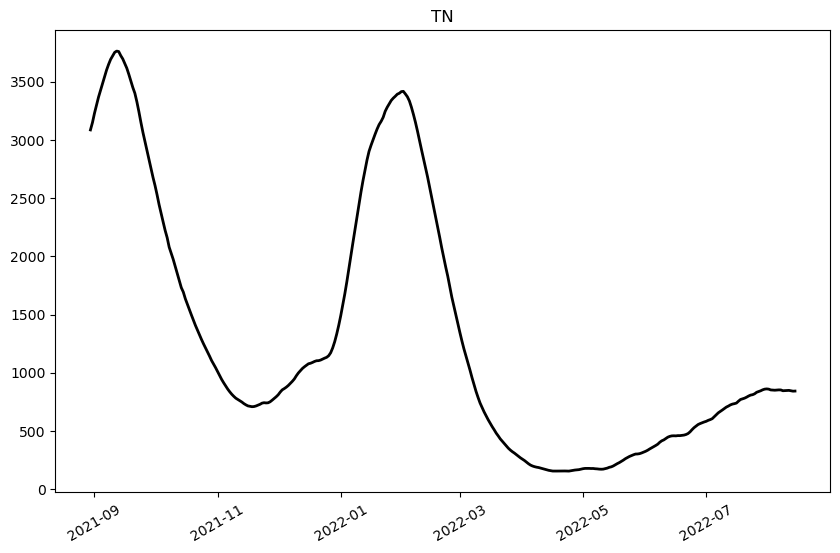

In [14]:
for state in ['MA', 'CT', 'NY', 'RI', 'ID', 'OR', 'TN']:
    plt.figure(figsize=(10, 6))
    plt.plot([datetime.strptime(str(d), '%Y%m%d') for d in test_dates], target_data[state], c = 'k', lw = 2)
    plt.title(state)
    plt.xticks(rotation = 30)

In [ ]:




data_handler = HealthDataHandler(state_list, lag_set, report_freq_days, target_data, state_data_dict)
    
DiagnosisCodeSet = Strong + Weak
active_g_indices = np.where(np.isin(all_codes, DiagnosisCodeSet))[0]
active_v_indices = extend_indices(active_g_indices, group_size)
y_dict = {}
pred_dict = {}
pred_agg_dict = {}
date_plot_list = []
for state in state_list:
    y_dict[state] = []
    pred_dict[state] = []
    pred_agg_dict[state] = []

selection = False
# for d_idx in range(len(train_start_date_list)):
d_idx = 0
data_handler.get_X_y(start_date = train_start_date_list[d_idx], end_date = validation_start_date_list[d_idx], codes = all_codes)
data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = validation_period)
print(train_start_date_list[d_idx], '-', test_start_date_list[d_idx])

# data_handler.run_all_single(intercept_length, method, alpha = 0.2, states_prev_g = states_prev_g, maxsteps = 4, states_prev_W = states_prev_W, tau = 0.5, M = 10, M_max = 30, fdr = 0.1)
data_handler.recovered_coef = {}
data_handler.recovered_intercept = {}
for state in state_list:
    grouped_X = data_handler.grouped_X[state]
    y = data_handler.y[state]
    X_active = grouped_X[:, active_v_indices]
    extended_X_active = np.hstack([np.ones((grouped_X.shape[0], 1)), X_active])
    beta, _, _, _ = np.linalg.lstsq(extended_X_active, y, rcond=None)
    recovered_coef = np.zeros(grouped_X.shape[1])
    recovered_coef[active_v_indices] = beta[1:]
    recovered_intercept = recover_intercept(grouped_X, y, recovered_coef, intercept_length)
    data_handler.recovered_coef[state] = recovered_coef
    data_handler.recovered_intercept[state] = recovered_intercept

data_handler.run_all_agg(intercept_length, state_method = 'marginal_diff', auxiliary_state_list = None, nStates = 5, total_step = 10, selection = selection)

data_handler.get_test(start_test = validation_start_date_list[d_idx], codes = all_codes, period_length = test_period)
date_plot_list.append([datetime.strptime(str(d), '%Y%m%d') for d in data_handler.test_dates])
for state in state_list:
    y_dict[state].append(data_handler.y_test[state])
    pred_dict[state].append(np.dot(data_handler.grouped_X_test[state], data_handler.recovered_coef[state]) + data_handler.recovered_intercept[state])
    pred_agg_dict[state].append(np.dot(data_handler.grouped_X_test[state], data_handler.recovered_coef_agg[state]) + data_handler.recovered_intercept_agg[state])

for state in ['PA', 'NY', 'NJ', 'MA', 'OH', 'VA', 'MD', 'CT', 'RI']:
    plt.figure(figsize=(10, 6))
    plt.plot(date_plot_list[d_idx], y_dict[state][d_idx], c = 'k', lw = 2)
    plt.plot(date_plot_list[d_idx], pred_dict[state][d_idx], alpha = 0.8, c = 'r', lw = 1, label = 'single model')
    plt.plot(date_plot_list[d_idx], pred_agg_dict[state][d_idx], alpha = 0.8, c = 'g', lw = 1, label = 'aggregated model')
    plt.legend()
    plt.title(state)
    plt.xticks(rotation = 30)
    
